## 20. Μάθηση με πολωμένο σήμα

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Η επιβλεπόμενη μηχανική μάθηση βασίζεται σε μια φαινομενικά απλή υπόθεση, ότι κάθε παράδειγμα συνοδεύεται από μία σωστή ετικέτα ή τιμή. Η υπόθεση αυτή βρίσκεται στον πυρήνα σχεδόν όλων των σύγχρονων συστημάτων μηχανικής μάθησης, από την ταξινόμηση εικόνων μέχρι την επεξεργασία φυσικής γλώσσας. Στην πράξη, όμως, η υπόθεση αυτή δεν είναι πάντα σωστή.

Σε πολλά πραγματικά προβλήματα, και ιδιαίτερα σε όσα εμπλέκουν την ανθρώπινη κρίση, οι ετικέτες δεν είναι μοναδικές ούτε αντικειμενικές. Αντίθετα, προκύπτουν από πολλούς επισημειωτές, οι οποίοι μπορεί κάλλιστα να διαφωνούν. Και η διαφωνία αυτή δεν οφείλεται απαραίτητα στο λάθος. Μπορεί, για παράδειγμα, να είναι λόγω διαφορετικών εμπειριών ή αξιών. Για να γίνει πιο συγκεκριμένο το παράδειγμα αυτό, σκεφτείτε ένα σχόλιο που θεωρείται επιθετικό από κάποιους και αποδεκτό από άλλους· μια πρόταση μπορεί να εκλαμβάνεται ως ειρωνική ή κυριολεκτική· μια παροιμία μπορεί να ενεργοποιεί διαφορετικές πολιτισμικές αναγνώσεις. Αυτά είναι παραδείγματα που συμβαίνουν στον πραγματικό κόσμο.

Η καθιερωμένη πρακτική στη μηχανική μάθηση είναι να εξομαλύνει αυτές τις διαφωνίες, συνήθως μέσω μιας πλειοψηφικής ψήφου (majority vote). Με αυτόν τον τρόπο, οι πολλαπλές απόψεις συμπυκνώνονται σε μία τελική ετικέτα, την οποία το μοντέλο καλείται να μάθει. Ωστόσο, αυτή η διαδικασία συνεπάγεται μια σημαντική απώλεια πληροφορίας που αφορά την ίδια τη διαφωνία, δηλαδή το ποιοι διαφωνούν και πόσο έντονα.


In [ ]:
def dfu(input_data, histogram_input=True, normalised=True):
  hist = input_data if histogram_input else to_hist(input_data)
  max_value = max(hist)
  pos_max = np.where(hist == max_value)[0][0]
  max_diff = 0
  for i in range(pos_max, len(hist)-1):
    diff = hist[i+1]-hist[i]
    if diff > max_diff:
      max_diff = diff
  for i in range(pos_max, 0, -1):
    diff = hist[i-1]-hist[i]
    if diff > max_diff:
      max_diff = diff
  if normalised:
    return max_diff / max_value
  return max_diff

def to_hist(scores, bins_num=3, normed=True):
  counts, bins = np.histogram(a=scores, bins=bins_num)
  counts_normed = counts/counts.sum()
  return counts_normed if normed else counts

In [ ]:
def normalize(x):
    x = np.array(x, dtype=float)
    return x / x.sum()

# 1. Μονοκορυφική (Gaussian-like)
f1 = normalize([1, 3, 6, 4, 2])

# 2. Ομοιόμορφη
f2 = normalize([1, 1, 1, 1, 1])

# 3. Διπολική (bimodal)
f3 = normalize([5, 1, 0, 1, 5])

# 4. Τριπολική
f4 = normalize([3, 0, 3, 0, 3])

In [ ]:
for i, f in enumerate([f1, f2, f3, f4], start=1):
    print(f"f{i} =", f, "DFU =", dfu(f))

f1 = [0.0625 0.1875 0.375  0.25   0.125 ] DFU = 0.0
f2 = [0.2 0.2 0.2 0.2 0.2] DFU = 0.0
f3 = [0.41666667 0.08333333 0.         0.08333333 0.41666667] DFU = 0.8
f4 = [0.33333333 0.         0.33333333 0.         0.33333333] DFU = 1.0


In [ ]:
np.random.seed(42)

# 1. Μονοκορυφική (Gaussian)
data1 = np.random.normal(loc=5, scale=1.5, size=1000)

# 2. Ομοιόμορφη
data2 = np.random.uniform(low=1, high=9, size=1000)

# 3. Διπολική
data3 = np.concatenate([
    np.random.normal(2, 0.5, 500),
    np.random.normal(8, 0.5, 500)
])

# 4. Τριπολική
data4 = np.concatenate([
    np.random.normal(2, 0.5, 300),
    np.random.normal(5, 0.5, 300),
    np.random.normal(8, 0.5, 300)
])

In [ ]:
datasets = [data1, data2, data3, data4]
names = ["Unimodal", "Uniform", "Bimodal", "Trimodal"]

for name, data in zip(names, datasets):
    hist = to_hist(data, bins_num=5)
    print(name, "DFU =", dfu(hist))

Unimodal DFU = 0.0
Uniform DFU = 0.12962962962962962
Bimodal DFU = 0.564516129032258
Trimodal DFU = 0.6776556776556776


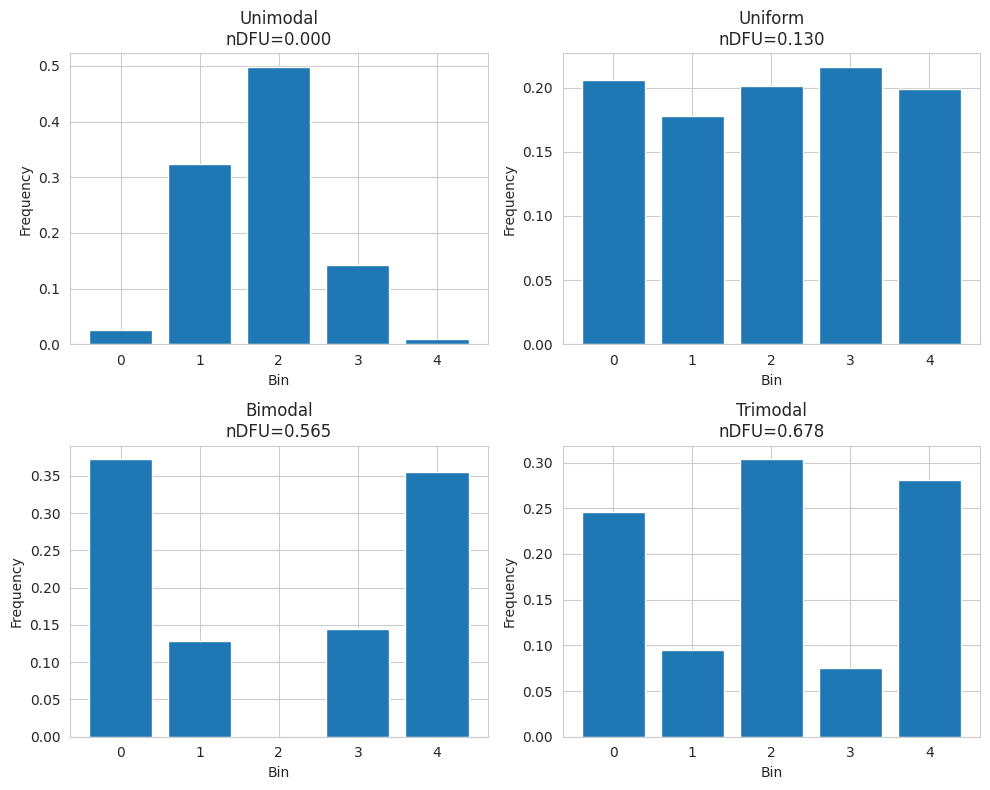

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, data, name in zip(axes.flatten(), datasets, names):
    hist = to_hist(data, bins_num=5)
    score = dfu(hist)

    ax.bar(range(len(hist)), hist)
    ax.set_title(f"{name}\nnDFU={score:.3f}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# Δοκίμασε διαφορετικά bins
for bins in [3, 5, 10]:
    hist = to_hist(data3, bins_num=bins)
    print(f"Bins={bins}, DFU={dfu(hist):.3f}")

Bins=3, DFU=0.996
Bins=5, DFU=0.565
Bins=10, DFU=0.519


### Συνθετικά δεδομένα με αντικρουόμενες ιδιότητες

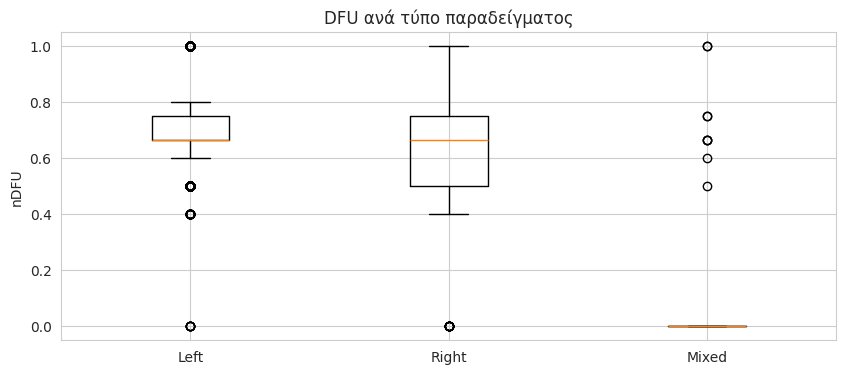

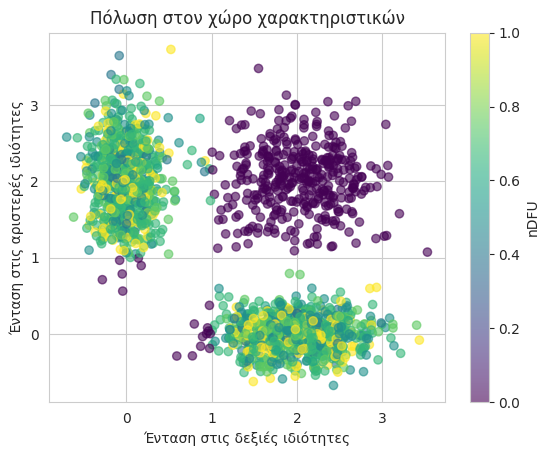

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N, d = 2000, 10
left_dims = slice(0, d//2)
right_dims = slice(d//2, d)

X = np.zeros((N, d))
labels_type = []

# --- δημιουργία δεδομένων ---
for i in range(N):
    r = np.random.rand()

    if r < 0.4:
        X[i, left_dims] = np.random.normal(2, 1, d//2)
        X[i, right_dims] = np.random.normal(0, 0.5, d//2)
        labels_type.append("left")

    elif r < 0.8:
        X[i, left_dims] = np.random.normal(0, 0.5, d//2)
        X[i, right_dims] = np.random.normal(2, 1, d//2)
        labels_type.append("right")

    else:
        X[i, left_dims] = np.random.normal(2, 1, d//2)
        X[i, right_dims] = np.random.normal(2, 1, d//2)
        labels_type.append("mixed")

# --- annotators ---
def annotate(x, A=9):
    anns = []

    left_score = x[left_dims].mean()
    right_score = x[right_dims].mean()

    for a in range(A):

        if left_score > 1 and right_score > 1:
            # MIXED → συμφωνία (υψηλές τιμές)
            anns.append(np.random.choice([4,5]))

        elif left_score > 1:
            # LEFT → πόλωση
            if a < A//2:
                anns.append(np.random.choice([1,2]))
            else:
                anns.append(np.random.choice([4,5]))

        elif right_score > 1:
            # RIGHT → πόλωση
            if a < A//2:
                anns.append(np.random.choice([1,2]))
            else:
                anns.append(np.random.choice([4,5]))

        else:
            anns.append(3)

    return np.array(anns)

# --- DFU ---
def to_hist(scores, bins_num=5, range=(1,6), normed=True):
    counts, _ = np.histogram(scores, bins=bins_num, range=range)
    return counts/counts.sum() if normed else counts

def dfu(hist):
    max_value = max(hist)
    pos_max = np.argmax(hist)
    max_diff = 0

    for i in range(pos_max, len(hist)-1):
        max_diff = max(max_diff, hist[i+1]-hist[i])

    for i in range(pos_max, 0, -1):
        max_diff = max(max_diff, hist[i-1]-hist[i])

    return max_diff / max_value

# --- υπολογισμοί ---
dfu_scores = []
majority_labels = []

for x in X:
    ann = annotate(x)
    hist = to_hist(ann)
    dfu_scores.append(dfu(hist))
    majority_labels.append(np.bincount(ann).argmax())

dfu_scores = np.array(dfu_scores)

# --- boxplot ---
left_scores = dfu_scores[np.array(labels_type)=="left"]
right_scores = dfu_scores[np.array(labels_type)=="right"]
mixed_scores = dfu_scores[np.array(labels_type)=="mixed"]

plt.figure(figsize=(10,4))
plt.boxplot([left_scores, right_scores, mixed_scores],
            tick_labels=["Left","Right","Mixed"])
plt.title("DFU ανά τύπο παραδείγματος")
plt.ylabel("nDFU")
plt.show()

# --- 2D visualization ---
left_strength = X[:, left_dims].mean(axis=1)
right_strength = X[:, right_dims].mean(axis=1)

plt.scatter(right_strength, left_strength,
            c=dfu_scores, cmap='viridis', alpha=0.6)

plt.xlabel("Ένταση στις δεξιές ιδιότητες")
plt.ylabel("Ένταση στις αριστερές ιδιότητες")
plt.title("Πόλωση στον χώρο χαρακτηριστικών")
plt.colorbar(label="nDFU")
plt.show()

#### Μοντελοποίηση της K+1 κατηγορίας

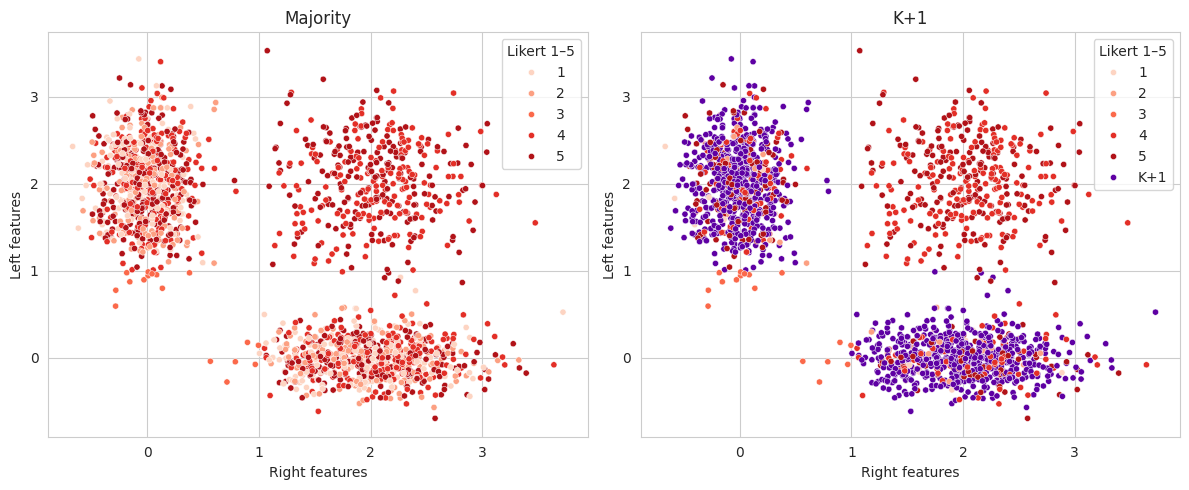

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.set_style('whitegrid')

# majority baseline
y_majority = np.array(majority_labels)

# K+1 labels με κατώφλι
threshold = 0.6  # πιο χαλαρό για να πιάσουμε polarization

y_kplus1 = []

for score, y in zip(dfu_scores, y_majority):
    if score > threshold:
        y_kplus1.append(6)   # νέα κλάση (polarized)
    else:
        y_kplus1.append(y)

y_kplus1 = np.array(y_kplus1)

left_strength = X[:, right_dims].mean(axis=1)
right_strength = X[:, left_dims].mean(axis=1)

map_labels = lambda y: ["K+1" if v==6 else str(v) for v in y]

base = sns.color_palette("Reds", 5)
palette = {str(i+1): base[i] for i in range(5)} | {"K+1": "#5e00a3"}
order = ["1","2","3","4","5","K+1"]

fig, ax = plt.subplots(1,2,figsize=(12,5))
# Majority
sns.scatterplot(x=right_strength, y=left_strength,
                hue=map_labels(y_majority), hue_order=order[:-1],
                palette=palette, s=20, ax=ax[0])
ax[0].set(title="Majority", xlabel="Right features", ylabel="Left features")
# K+1
sns.scatterplot(x=right_strength, y=left_strength,
                hue=map_labels(y_kplus1), hue_order=order,
                palette=palette, s=20, ax=ax[1])

ax[1].set(title="K+1", xlabel="Right features", ylabel="Left features")
ax[0].legend(title="Likert 1–5")
ax[1].legend(title="Likert 1–5")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_m_tr, y_m_te, y_k_tr, y_k_te = train_test_split(
    X, y_majority, y_kplus1, test_size=0.2, random_state=2026
)

from sklearn.ensemble import RandomForestClassifier
m_m = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_tr, y_m_tr)
m_k = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_tr, y_k_tr)

#from sklearn.linear_model import LogisticRegression
#m_m = LogisticRegression().fit(X_tr, y_m_tr)
#m_k = LogisticRegression().fit(X_tr, y_k_tr)

# --- predictions ---
y_pred_m = m_m.predict(X_te)
y_pred_k = m_k.predict(X_te)

# --- map K+1 → 1–5 με βάση τις πιθανότητες ---
import numpy as np
probs = m_k.predict_proba(X_te)
classes = m_k.classes_
valid_idx = [i for i,c in enumerate(classes) if c != 6]

mapped = []
for i, p in enumerate(y_pred_k):
    if p == 6:
        best = valid_idx[np.argmax(probs[i, valid_idx])]
        mapped.append(classes[best])
    else:
        mapped.append(p)
y_pred_k_map = np.array(mapped)

# --- evaluation ---
from sklearn.metrics import classification_report, accuracy_score
print("=== Majority ===")
print("Accuracy:", accuracy_score(y_m_te, y_pred_m))
print(classification_report(y_m_te, y_pred_m, zero_division=0))

print("\n=== K+1 (mapped back) ===")
print("Accuracy:", accuracy_score(y_m_te, y_pred_k_map))
print(classification_report(y_m_te, y_pred_k_map, zero_division=0))

=== Majority ===
Accuracy: 0.26
              precision    recall  f1-score   support

           1       0.26      0.15      0.19        75
           2       0.13      0.11      0.12        62
           3       0.00      0.00      0.00         3
           4       0.26      0.30      0.28       122
           5       0.31      0.36      0.33       138

    accuracy                           0.26       400
   macro avg       0.19      0.18      0.18       400
weighted avg       0.25      0.26      0.25       400


=== K+1 (mapped back) ===
Accuracy: 0.3425
              precision    recall  f1-score   support

           1       0.50      0.01      0.03        75
           2       0.00      0.00      0.00        62
           3       0.67      0.67      0.67         3
           4       0.30      0.49      0.37       122
           5       0.39      0.54      0.45       138

    accuracy                           0.34       400
   macro avg       0.37      0.34      0.30       400
w

In [ ]:
print("Predicted K+1:", np.sum(y_pred_k == 6))

Predicted K+1: 339


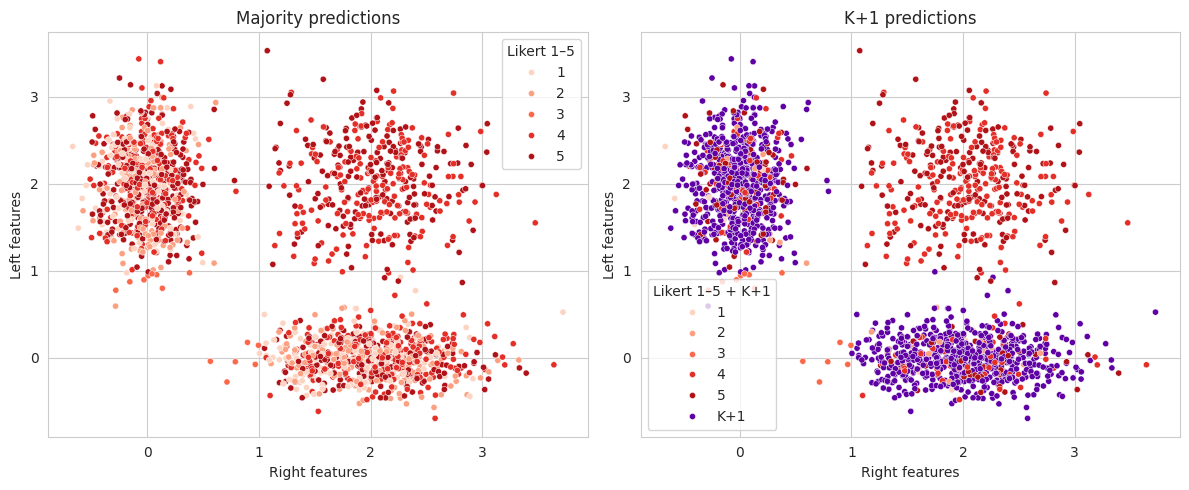

In [ ]:
y_pred_m = m_m.predict(X)
y_pred_k = m_k.predict(X)

import seaborn as sns, matplotlib.pyplot as plt
sns.set_style('whitegrid')

left_strength = X[:, right_dims].mean(axis=1)
right_strength = X[:, left_dims].mean(axis=1)

map_labels = lambda y: ["K+1" if v==6 else str(v) for v in y]

base = sns.color_palette("Reds", 5)
palette = {str(i+1): base[i] for i in range(5)} | {"K+1": "#5e00a3"}
order = ["1","2","3","4","5","K+1"]

fig, ax = plt.subplots(1,2,figsize=(12,5))

# Majority (predictions)
sns.scatterplot(x=right_strength, y=left_strength,
                hue=map_labels(y_pred_m), hue_order=order[:-1],
                palette=palette, s=20, ax=ax[0])

ax[0].set(title="Majority predictions",
          xlabel="Right features", ylabel="Left features")

# K+1 (predictions)
sns.scatterplot(x=right_strength, y=left_strength,
                hue=map_labels(y_pred_k), hue_order=order,
                palette=palette, s=20, ax=ax[1])

ax[1].set(title="K+1 predictions",
          xlabel="Right features", ylabel="Left features")

ax[0].legend(title="Likert 1–5")
ax[1].legend(title="Likert 1–5 + K+1")

plt.tight_layout()
plt.show()

### Εφαρμογή: Επιθετικά σχόλια και αντίληψη ανα διάσταση

In [ ]:
import pandas as pd

off_posts = pd.read_csv('https://github.com/Jiaxin-Pei/Potato-Prolific-Dataset/raw/refs/heads/main/dataset/offensiveness/raw_data.csv')
off_posts.sample()

,instance_id,user_id,text,offensiveness,gender,race,age,occupation,education
10559,658,212,"""honey are you sick? You've been taking allloo...",4.0,Woman,Black or African American,40-44,Employed,College degree


In [ ]:
grouped = off_posts.groupby("text").agg({
    "offensiveness": list,
    "gender": list
}).reset_index()
print(grouped.shape)
grouped.iloc[0]

(1500, 3)


,0
text,""" I didn't get very many trophies this year""--..."
offensiveness,"[2.0, 1.0, 1.0, 3.0, 4.0, 1.0, 1.0]"
gender,"[Woman, Woman, Man, Non-binary, Man, Man, Man]"


In [ ]:
import numpy as np

def to_hist(scores, bins_num=5, range=(1,6), normed=True):
    counts, _ = np.histogram(scores, bins=bins_num, range=range)
    return counts/counts.sum() if normed else counts

def dfu(hist):
    max_value = max(hist)
    pos_max = np.argmax(hist)
    max_diff = 0
    for i in range(pos_max, len(hist)-1):
        max_diff = max(max_diff, hist[i+1]-hist[i])
    for i in range(pos_max, 0, -1):
        max_diff = max(max_diff, hist[i-1]-hist[i])
    return max_diff / max_value

grouped["hist"] = grouped["offensiveness"].apply(to_hist)
grouped["ndfu"] = grouped["hist"].apply(dfu)

In [ ]:
polarized = grouped[grouped["ndfu"] > 0.3]
polarized.shape

(309, 5)

In [ ]:
from collections import defaultdict

def split_by_group(annotations, groups):
    out = defaultdict(list)
    for a, g in zip(annotations, groups): out[g].append(a)
    return out

def explains_polarization(annotations, groups):
    hist = to_hist(annotations)
    overall = dfu(hist)
    if overall == 0:
        return False  # δεν υπάρχει πόλωση
    splits = split_by_group(annotations, groups)
    for g in splits:
        if len(splits[g]) < 2:
            return False  # unstable
        if dfu(to_hist(splits[g])) > 0:
            return False  # group δεν είναι unimodal
    return True

grouped["explained"] = grouped.apply(
    lambda row: explains_polarization(row["offensiveness"], row["gender"]),
    axis=1
)

In [ ]:
interesting = grouped[
    (grouped["ndfu"] > 0.3) &
    (grouped["explained"])
]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_example(annotations, groups):
    splits = split_by_group(annotations, groups)
    plt.figure(figsize=(10,2))
    # overall
    plt.subplot(1, len(splits)+1, 1)
    plt.bar(range(1,6), to_hist(annotations))
    plt.title("Overall")
    # per group
    for i, (g, vals) in enumerate(splits.items()):
        plt.subplot(1, len(splits)+1, i+2)
        plt.bar(range(1,6), to_hist(vals))
        plt.title(g)
    sns.despine()
    plt.show()

Women have not spent years being told that their value as human beings is tied to the money they bring in. It would honestly surprise me a lot if women cared as much about pay as men do.


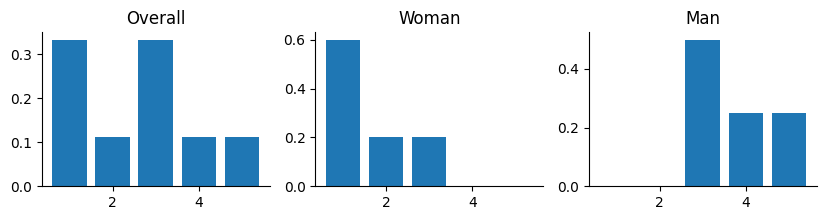

In [ ]:
row = interesting.sample(1).iloc[0]
print(row.text)
plot_example(row["offensiveness"], row["gender"])

If we’re talking about women the absolutely. Unpopular opinion but I think female sex workers are the only honest women. They’re straightforward about the fact that their only use for men is money, and they know that men want sex. They cut out all the bullshit and get to the point. I wish all women were that honest.


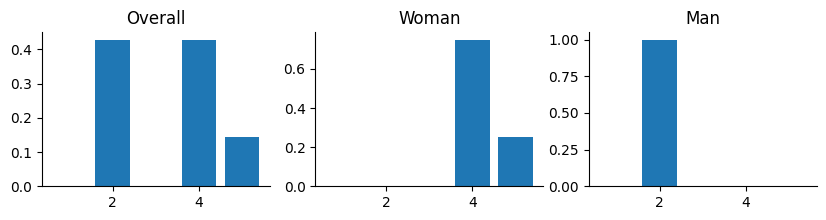

In [ ]:
row = interesting.sample(1).iloc[0]
print(row.text)
plot_example(row["offensiveness"], row["gender"])

So gay incest is okay?


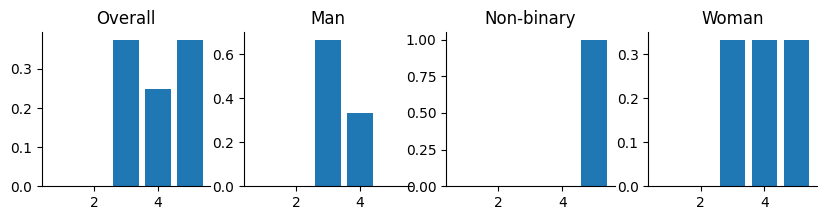

In [ ]:
row = interesting.sample(1).iloc[0]
print(row.text)
plot_example(row["offensiveness"], row["gender"])

In [ ]:
row

,620
text,If we’re talking about women the absolutely. U...
offensiveness,"[4.0, 4.0, 4.0, 5.0, 2.0, 2.0, 2.0]"
gender,"[Woman, Woman, Woman, Woman, Man, Man, Man]"
hist,"[0.0, 0.42857142857142855, 0.0, 0.428571428571..."
ndfu,1.0
explained,True


### Εφαρμογή: Ρητορική μίσους

In [ ]:
from datasets import load_dataset
hate_posts = load_dataset("ucberkeley-dlab/measuring-hate-speech")
df = hate_posts['train'].to_pandas()
df.describe()

,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,hatespeech,hate_speech_score,infitms,outfitms,annotator_severity,std_err,annotator_infitms,annotator_outfitms,hypothesis,annotator_age
count,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.00000,135556.000000,135556.000000,135556.000000,135556.000000,...,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135451.000000
mean,23530.416138,5567.097812,1.281352,2.954307,2.828875,2.56331,2.278638,2.698575,1.846211,1.052045,...,0.744733,-0.567428,1.034322,1.001052,-0.018817,0.300588,1.007158,1.011841,0.014589,37.910772
std,12387.194125,3230.508937,1.023542,1.231552,1.309548,1.38983,1.370876,0.898500,1.402372,1.345706,...,0.932260,2.380003,0.496867,0.791943,0.487261,0.236380,0.269876,0.675863,0.613006,11.641276
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.340000,0.100000,0.070000,-1.820000,0.020000,0.390000,0.280000,-1.578693,18.000000
25%,18148.000000,2719.000000,0.000000,2.000000,2.000000,2.00000,1.000000,2.000000,1.000000,0.000000,...,0.000000,-2.330000,0.710000,0.560000,-0.380000,0.030000,0.810000,0.670000,-0.341008,29.000000
50%,20052.000000,5602.500000,1.000000,3.000000,3.000000,3.00000,3.000000,3.000000,2.000000,0.000000,...,0.000000,-0.340000,0.960000,0.830000,-0.020000,0.340000,0.970000,0.850000,0.110405,35.000000
75%,32038.250000,8363.000000,2.000000,4.000000,4.000000,4.00000,3.000000,3.000000,3.000000,2.000000,...,2.000000,1.410000,1.300000,1.220000,0.350000,0.420000,1.170000,1.130000,0.449555,45.000000
max,50070.000000,11142.000000,3.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,...,2.000000,6.300000,5.900000,9.000000,1.360000,1.900000,2.010000,9.000000,0.987511,81.000000
